In [ ]:
# ============================================================
# CELL 1: IMPORT THƯ VIỆN
# ============================================================
# Chạy cell này đầu tiên. Nếu thiếu thư viện nào Colab báo lỗi
# ngay đây — dễ debug hơn là lỗi giữa chừng khi đang train.

import os, json, pickle, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_recall_curve, recall_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

warnings.filterwarnings('ignore')

# Cố định seed để kết quả reproducible — chạy lại ra kết quả giống nhau
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Kiểm tra GPU — có GPU thì train nhanh hơn ~10x
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__} | GPU: {gpus}')

if gpus:
    # Không cấp hết VRAM ngay từ đầu, dùng bao nhiêu cấp bấy nhiêu
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        # Mixed precision fp16: tăng tốc ~2x trên T4/A100, accuracy không đổi
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision: ON')
    except Exception as e:
        print(f'Mixed precision N/A: {e}')
else:
    print('⚠️  Không có GPU — vào Runtime > Change runtime type > T4 GPU')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Import xong.')

TensorFlow : 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: ON
✅ Import xong.


In [ ]:
# ============================================================
# CELL 2: CONFIG & ĐƯỜNG DẪN DATA
# ============================================================
# Tất cả tham số quan trọng tập trung ở đây.
# Muốn thay đổi bất cứ thứ gì → sửa ở cell này, KHÔNG sửa rải rác.

# Mount Google Drive để đọc data và lưu model
IN_COLAB = 'google.colab' in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ── Đường dẫn 6 subjects ─────────────────────────────────────
# Cập nhật so với notebook cũ: thêm An, Hao, Quan (trước chỉ có Hieu, Kien, Tien)
DATA_ROOTS = [
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/An'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hao'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hieu'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Kien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Quan'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Tien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Cong'),
]
OUTPUT_DIR = Path('/content/drive/MyDrive/data_pbl5/models_7_pers_lstm')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Tham số cảm biến & window ────────────────────────────────
SAMPLE_RATE   = 50      # ESP32 thu 50 mẫu/giây
WINDOW_SIZE   = 100     # 100 mẫu = 2 giây/window
OVERLAP_RATIO = 0.5     # Bước nhảy = 50 mẫu = 1 giây
NUM_CHANNELS  = 6       # ax, ay, az, gx, gy, gz
CLASS_NAMES   = ['Normal', 'Fall']
EXCLUDE_SUBFOLDERS = ['LonXon']
# ── Tham số training ─────────────────────────────────────────
TEST_SIZE     = 0.15    # 15% test (chỉ dùng cho lần train 1)
VAL_SIZE      = 0.15    # 15% validation
EPOCHS        = 150     # EarlyStopping sẽ dừng sớm nếu không cải thiện
BATCH_SIZE    = 32      # Nhỏ hơn 64 vì dataset không quá lớn
LEARNING_RATE = 5e-4    # Thấp hơn 1e-3 vì model có Attention nhạy cảm với LR cao
DROPOUT_RATE  = 0.35    # Regularization — tránh overfit trên dataset nhỏ
L2_REG        = 2e-4    # L2 weight decay thêm vào

# ── Tham số quan trọng nhất: số window "nóng" giữ lại từ Fall session ──
#
# VẤN ĐỀ GỐC RỄ khiến model cũ hay báo nhầm:
#   Quy trình thu data: bấm nút → té → nằm yên ~2-3s → tắt session
#   → Sliding window tạo ra nhiều window từ phần "nằm yên sau ngã"
#   → Những window này có magnitude ≈ 9.8 m/s² (trọng lực thuần)
#   → Trông GIỐNG HỆT người đứng/ngồi yên (Normal)
#   → Model học nhầm: "nằm yên = Fall" → false positive khi deploy
#
# GIẢI PHÁP: Chỉ giữ N_HOT_WINDOWS window ĐẦU TIÊN của mỗi Fall session
#   Bước nhảy = 50 mẫu = 1s → 8 windows đầu ≈ 8 giây đầu
#   8 giây đầu chứa: cú freefall + impact + vài giây nằm yên ngay sau ngã
#   Phần còn lại (nằm yên dài) bị loại bỏ
#
# Gợi ý: nếu session Fall của bạn ngắn (~3-4s) thì giảm xuống N_HOT_WINDOWS = 5
#         nếu dài hơn (~10s) thì tăng lên 10-12
N_HOT_WINDOWS = 5

print('✅ Config:')
print(f'  Window     : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLE_RATE:.1f}s @ {SAMPLE_RATE}Hz')
print(f'  Bước nhảy  : {int(WINDOW_SIZE*(1-OVERLAP_RATIO))} samples = {int(WINDOW_SIZE*(1-OVERLAP_RATIO)/SAMPLE_RATE*1000)}ms')
print(f'  Subjects   : {len(DATA_ROOTS)} người')
print(f'  Hot windows: giữ {N_HOT_WINDOWS} window đầu/Fall session (~{N_HOT_WINDOWS}s đầu)')
print(f'  Output dir : {OUTPUT_DIR}')

Mounted at /content/drive
✅ Config:
  Window     : 100 samples = 2.0s @ 50Hz
  Bước nhảy  : 50 samples = 1000ms
  Subjects   : 7 người
  Hot windows: giữ 5 window đầu/Fall session (~5s đầu)
  Output dir : /content/drive/MyDrive/data_pbl5/models_7_pers_lstm


In [ ]:
# ============================================================
# CELL 3: LOAD DATA
# ============================================================
def load_session(session_dir):
    session_dir = Path(session_dir)
    accel_path  = session_dir / 'accel.csv'
    gyro_path   = session_dir / 'gyro.csv'

    if not (accel_path.exists() and gyro_path.exists()):
        return None, None

    folder_name = session_dir.name
    label = None
    if folder_name.startswith('label'):
        try:
            label = int(folder_name[5])
        except (ValueError, IndexError):
            label = None
    if label is None:
        label_path = session_dir / 'label.txt'
        if label_path.exists():
            try:
                label = int(label_path.read_text().strip())
            except Exception:
                return None, None
        else:
            return None, None

    try:
        accel = pd.read_csv(accel_path)
        gyro  = pd.read_csv(gyro_path)
    except Exception:
        return None, None

    if accel.empty or gyro.empty:
        return None, None
    if accel.shape[1] != 4 or gyro.shape[1] != 4:
        return None, None

    accel.columns = ['time', 'ax', 'ay', 'az']
    gyro.columns  = ['time', 'gx', 'gy', 'gz']

    min_len = min(len(accel), len(gyro))
    df = pd.concat([
        accel[['ax', 'ay', 'az']].iloc[:min_len].reset_index(drop=True),
        gyro [['gx', 'gy', 'gz']].iloc[:min_len].reset_index(drop=True),
    ], axis=1)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    if len(df) < WINDOW_SIZE // 2:
        return None, None

    return df, label


def load_all_sessions(data_roots):
    sessions = []
    stats = {name: 0 for name in CLASS_NAMES}
    stats['errors'] = stats['skipped'] = 0

    def find_session_dirs(base_dir):
        result = []
        if not base_dir.exists():
            return result
        for entry in sorted(base_dir.iterdir()):
            if entry.is_dir():
                if (entry / 'accel.csv').exists():
                    result.append(entry)
                else:
                    result.extend(find_session_dirs(entry))
        return result

    for root in data_roots:
        root        = Path(root)
        person_name = root.name
        print(f'\n📁 {root}  [subject={person_name}]')

        for class_name in CLASS_NAMES:
            class_dir = root / class_name
            if not class_dir.exists():
                print(f'   ⚠️  Thiếu thư mục: {class_dir}')
                continue

            sess_dirs = find_session_dirs(class_dir)

            # ── Filter EXCLUDE_SUBFOLDERS ─────────────────────
            before = len(sess_dirs)
            sess_dirs = [
                sd for sd in sess_dirs
                if not any(ex in sd.parts for ex in EXCLUDE_SUBFOLDERS)
            ]
            after = len(sess_dirs)
            if before != after:
                print(f'   🗑️  {class_name}: bỏ {before - after} sessions '
                      f'({EXCLUDE_SUBFOLDERS}) → còn {after}')

            print(f'   {class_name}: {len(sess_dirs)} sessions')

            subfolder_counts = {}
            for sd in sess_dirs:
                try:
                    subfolder = sd.relative_to(class_dir).parts[0]
                except Exception:
                    subfolder = '(root)'
                subfolder_counts[subfolder] = subfolder_counts.get(subfolder, 0) + 1
            for sf, cnt in sorted(subfolder_counts.items()):
                print(f'      └─ {sf}: {cnt}')

            expected_label = CLASS_NAMES.index(class_name)
            for sess_dir in sess_dirs:
                df, lbl = load_session(sess_dir)
                if df is None:
                    stats['errors'] += 1
                    continue
                if lbl != expected_label:
                    print(f'   ⚠️  Label mismatch: {sess_dir.name} '
                          f'(file={lbl}, expected={expected_label})')
                    stats['skipped'] += 1
                    continue
                stats[class_name] += 1
                sessions.append((df, lbl, person_name))

    print('\n' + '─' * 50)
    total = sum(stats[c] for c in CLASS_NAMES)
    print(f'📊 Tổng sessions hợp lệ: {total}')
    for c in CLASS_NAMES:
        print(f'   {c:7}: {stats[c]}')
    print(f'   Lỗi / mismatch: {stats["errors"]} / {stats["skipped"]}')

    if not sessions:
        raise ValueError('❌ Không có session nào.')
    found_labels = {lbl for _, lbl, _ in sessions}
    if len(found_labels) < 2:
        raise ValueError(f'❌ Chỉ có 1 class.')
    return sessions


all_sessions = load_all_sessions(DATA_ROOTS)
print(f'\n✅ Load xong: {len(all_sessions)} sessions.')


📁 /content/drive/MyDrive/data_pbl5/Self-Collected/An  [subject=An]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hao  [subject=Hao]
   Normal: 52 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 17
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hieu  [subject=Hieu]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 51 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 26

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Kien  [subject=Kien]
   Normal: 45 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 11
      └─ GoPhim: 10
      └─ LuotDienThoai: 9
   Fall: 36 sessions
      └─ NgaRaSau: 18
      └─ NgaRaTruoc: 18

📁 

📊 Phân bố sessions theo subject:
Subject      Normal     Fall    Total
──────────────────────────────────────
An               50       50      100
Cong             52       60      112
Hao              52       50      102
Hieu             50       51      101
Kien             45       36       81
Quan             51       50      101
Tien             52       50      102


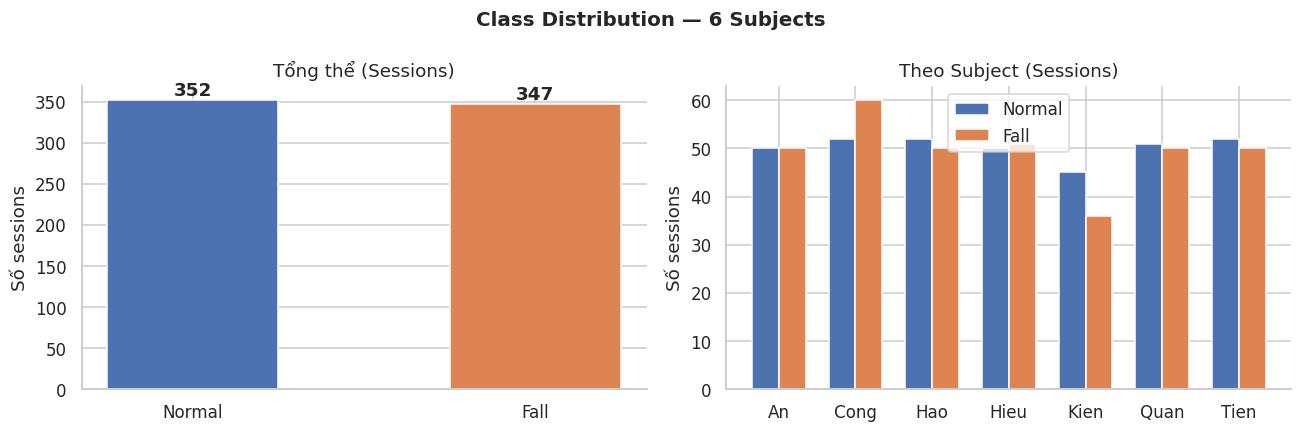


⚠️  Nếu subject nào có số Fall = 0 hoặc Normal = 0
   thì fold LOSO tương ứng sẽ bị bỏ qua tự động.


In [ ]:
# ============================================================
# CELL 4: VISUALIZE PHÂN BỐ DATA
# ============================================================
# Kiểm tra xem mỗi subject có bao nhiêu session Normal / Fall.
# Nếu 1 subject chỉ có Normal hoặc chỉ có Fall → LOSO fold đó sẽ bị bỏ qua.

# Thống kê theo subject
print('📊 Phân bố sessions theo subject:')
print(f'{"Subject":<10} {"Normal":>8} {"Fall":>8} {"Total":>8}')
print('─' * 38)
subject_stats = {}
for _, lbl, person in all_sessions:
    if person not in subject_stats:
        subject_stats[person] = [0, 0]
    subject_stats[person][lbl] += 1
for person, counts in sorted(subject_stats.items()):
    total = sum(counts)
    print(f'{person:<10} {counts[0]:>8} {counts[1]:>8} {total:>8}')

labels_all   = [lbl for _, lbl, _ in all_sessions]
label_counts = {name: labels_all.count(i) for i, name in enumerate(CLASS_NAMES)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — 6 Subjects', fontsize=13, fontweight='bold')

# Biểu đồ tổng thể
bars = axes[0].bar(CLASS_NAMES, [label_counts[n] for n in CLASS_NAMES],
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Tổng thể (Sessions)')
axes[0].set_ylabel('Số sessions')
sns.despine(ax=axes[0])

# Biểu đồ theo subject
subjects = sorted(subject_stats.keys())
x        = np.arange(len(subjects))
w        = 0.35
axes[1].bar(x - w/2, [subject_stats[s][0] for s in subjects], w,
            label='Normal', color='#4C72B0')
axes[1].bar(x + w/2, [subject_stats[s][1] for s in subjects], w,
            label='Fall',   color='#DD8452')
axes[1].set_title('Theo Subject (Sessions)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(subjects)
axes[1].legend()
axes[1].set_ylabel('Số sessions')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print('\n⚠️  Nếu subject nào có số Fall = 0 hoặc Normal = 0')
print('   thì fold LOSO tương ứng sẽ bị bỏ qua tự động.')

In [ ]:
# ============================================================
# CELL 5: SLIDING WINDOW + LABEL REFINEMENT
# ============================================================
#
# ĐÂY LÀ THAY ĐỔI QUAN TRỌNG NHẤT so với notebook cũ.
#
# VẤN ĐỀ: Quy trình thu data Fall = bấm nút → té → nằm yên → tắt
#   Sliding window trên toàn session tạo ra 2 loại window:
#     [1] Window đầu: freefall + impact  → magnitude biến động mạnh ✅ đúng là Fall
#     [2] Window sau: nằm yên bất động   → magnitude ≈ 9.8 m/s² (trọng lực thuần)
#   Window loại [2] giống hệt "đứng/ngồi yên" trong Normal.
#   Nếu giữ hết → model học: "bất động = Fall" → false positive khi deploy.
#
# GIẢI PHÁP: chỉ giữ N_HOT_WINDOWS window đầu của mỗi Fall session.
#   Với bước nhảy 1s: 8 windows = ~8 giây đầu = đủ bắt cú ngã thật.
#   Phần "nằm yên dài" phía sau bị loại bỏ hoàn toàn.
#
# Normal session: giữ toàn bộ windows (không thay đổi gì).

def sliding_window(data_array, window_size, overlap_ratio):
    """Tạo list các windows từ array dữ liệu cảm biến."""
    step = max(int(window_size * (1 - overlap_ratio)), 1)
    return [
        data_array[start : start + window_size]
        for start in range(0, len(data_array) - window_size + 1, step)
    ]


def build_windows(sessions, window_size, overlap_ratio, n_hot_windows):
    """
    Tạo windows từ tất cả sessions, áp dụng label refinement cho Fall.

    Trả về:
      X       : (N, window_size, 6) — array dữ liệu cảm biến
      y       : (N,)               — nhãn 0/1
      persons : (N,)               — tên subject (dùng cho LOSO)
    """
    X_list, y_list, person_list = [], [], []
    fall_total = 0
    fall_kept  = 0
    normal_total = 0

    for df, label, person in sessions:
        arr  = df[['ax','ay','az','gx','gy','gz']].values.astype(np.float32)
        wins = sliding_window(arr, window_size, overlap_ratio)

        if label == 1:  # Fall session → chỉ giữ n_hot_windows đầu
            fall_total += len(wins)
            wins = wins[:n_hot_windows]
            fall_kept += len(wins)
        else:           # Normal session → giữ hết
            normal_total += len(wins)

        for w in wins:
            X_list.append(w)
            y_list.append(label)
            person_list.append(person)

    X       = np.array(X_list,   dtype=np.float32)
    y       = np.array(y_list,   dtype=np.int32)
    persons = np.array(person_list)

    print('── Label Refinement Summary ────────────────────────────')
    print(f'Normal windows (giữ hết)   : {normal_total}')
    print(f'Fall windows trước khi trim: {fall_total}')
    print(f'Fall windows sau khi trim  : {fall_kept}  '
          f'(giữ {fall_kept/fall_total*100:.1f}%)')
    print(f'Đã loại bỏ {fall_total - fall_kept} window "nằm yên sau ngã"')
    print()
    print(f'X shape : {X.shape}')
    print(f'Normal  : {int(np.sum(y == 0))} windows')
    print(f'Fall    : {int(np.sum(y == 1))} windows')
    ratio = np.sum(y == 0) / max(np.sum(y == 1), 1)
    print(f'Tỷ lệ N/F: {ratio:.2f}x '
          f'{"(cân bằng tốt ✅)" if ratio < 3 else "(còn lệch, class_weight sẽ bù)"}')
    return X, y, persons


X_raw, y_raw, persons_raw = build_windows(
    all_sessions, WINDOW_SIZE, OVERLAP_RATIO, N_HOT_WINDOWS
)

# Kiểm tra nhanh magnitude để confirm data hợp lý
mags = np.sqrt(np.sum(X_raw[:, :, :3] ** 2, axis=2))  # (N, T)
print(f'\nKiểm tra magnitude accelerometer:')
print(f'  Mean magnitude (Normal): {np.mean(mags[y_raw==0]):.2f} m/s²  '
      f'(kỳ vọng ~9.8)')
print(f'  Max  magnitude (Fall)  : {np.max(mags[y_raw==1]):.2f} m/s²  '
      f'(kỳ vọng > 20)')

── Label Refinement Summary ────────────────────────────
Normal windows (giữ hết)   : 1509
Fall windows trước khi trim: 2040
Fall windows sau khi trim  : 1712  (giữ 83.9%)
Đã loại bỏ 328 window "nằm yên sau ngã"

X shape : (3221, 100, 6)
Normal  : 1509 windows
Fall    : 1712 windows
Tỷ lệ N/F: 0.88x (cân bằng tốt ✅)

Kiểm tra magnitude accelerometer:
  Mean magnitude (Normal): 10.70 m/s²  (kỳ vọng ~9.8)
  Max  magnitude (Fall)  : 65.80 m/s²  (kỳ vọng > 20)


In [ ]:
# ============================================================
# CELL 6: ĐỊNH NGHĨA MODEL — CNN + LSTM + MULTIHEAD ATTENTION
# ============================================================
#
# TẠI SAO KHÔNG DÙNG BiLSTM (như notebook cũ)?
#   BiLSTM đọc sequence theo cả 2 chiều (forward + backward).
#   Chiều backward cần toàn bộ sequence trước khi xử lý.
#   → Không phù hợp realtime: trên thiết bị chỉ có data chiều forward.
#   → BiLSTM overfit hơn (tham số gấp đôi) trên dataset nhỏ.
#   → LSTM 1 chiều đủ học pattern: freefall (đầu window) → impact → still.
#
# KIẾN TRÚC:
#   Conv1D  → trích local features (jerk, đột biến gia tốc trong 5-10 mẫu)
#   LSTM    → học temporal dependency theo thứ tự thời gian
#   MHA     → học global pattern trong toàn window (freefall ở đầu, still ở cuối)
#   Dual pooling → avg giữ context tổng thể + max bắt đỉnh impact

try:
    register_serializable = tf.keras.utils.register_keras_serializable
except AttributeError:
    def register_serializable(**kwargs):
        def decorator(cls): return cls
        return decorator


@register_serializable(package='FallDetectionV3')
class MultiHeadSelfAttention(layers.Layer):
    """
    Multi-Head Self-Attention với residual connection + Layer Norm.
    4 heads học song song 4 pattern khác nhau:
      head 1: freefall (magnitude giảm đột ngột)
      head 2: impact   (magnitude tăng vọt)
      head 3: stillness (magnitude ổn định sau ngã)
      head 4: gyro rotation pattern
    Residual (x + attn_out) giúp gradient flow tốt hơn khi train sâu.
    """
    def __init__(self, num_heads=4, key_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim   = key_dim

    def build(self, input_shape):
        self.mha  = layers.MultiHeadAttention(
            num_heads=self.num_heads, key_dim=self.key_dim, dropout=0.1
        )
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        super().build(input_shape)

    def call(self, x, training=False):
        attn_out = self.mha(x, x, training=training)
        return self.norm(x + attn_out)   # residual connection

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return cfg


@register_serializable(package='FallDetectionV3')
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha=0.65):
    """
    Focal Loss thay cho Binary Cross-Entropy.

    Tại sao Focal Loss?
      BCE phạt đều mọi sample → model chú trọng vào easy cases (Normal rõ ràng).
      Focal Loss down-weight easy cases qua (1-p_t)^gamma → tập trung hard cases.

    alpha=0.65: tăng trọng số cho Fall (class dương).
      Miss detection (bỏ sót ngã) nguy hiểm hơn false alarm (báo nhầm).
      alpha > 0.5 → phạt nặng hơn khi bỏ sót Fall.
      Sau khi trim window, Fall có thể ít hơn Normal → cần bù thêm.

    gamma=2.0: down-weight mạnh easy examples.
      Normal đứng yên rõ ràng → model dễ predict đúng → weight thấp.
      Fall borderline (window gần cuối session) → weight cao → model học kỹ hơn.
    """
    y_true  = tf.cast(y_true, tf.float32)
    y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce     = -(y_true * tf.math.log(y_pred) +
                (1 - y_true) * tf.math.log(1 - y_pred))
    p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
    return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)


def build_model(input_shape):
    reg    = regularizers.l2(L2_REG)
    inputs = keras.Input(shape=input_shape, name='imu_input')

    # ── Block 1: Conv1D — local feature extraction ───────────
    # kernel_size=5: nhìn 5 mẫu liên tiếp (~100ms) để detect jerk cục bộ
    x = layers.Conv1D(32, kernel_size=5, padding='same',
                      activation='relu', kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    # kernel_size=3: tinh chỉnh feature sau lần Conv đầu
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)  # Giảm sequence 100 → 50
    x = layers.Dropout(DROPOUT_RATE * 0.4)(x)

    # ── Block 2: Conv1D thêm lần nữa ─────────────────────────
    x = layers.Conv1D(64, kernel_size=3, padding='same',
                      activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)  # Giảm 50 → 25
    x = layers.Dropout(DROPOUT_RATE * 0.4)(x)

    # ── Block 3: LSTM 1 chiều ─────────────────────────────────
    # return_sequences=True: trả về hidden state tại mỗi timestep
    # → Attention ở Block 4 cần toàn bộ sequence, không chỉ hidden state cuối
    # dropout/recurrent_dropout: regularization trong LSTM
    x = layers.LSTM(64,
                    return_sequences=True,
                    dropout=0.2,
                    recurrent_dropout=0.1,
                    kernel_regularizer=reg)(x)
    x = layers.Dropout(DROPOUT_RATE * 0.5)(x)

    # ── Block 4: Multi-Head Self-Attention ───────────────────
    # Học global pattern trong 25 timestep còn lại
    # (sau 2 lần MaxPooling từ 100 → 25)
    x = MultiHeadSelfAttention(num_heads=4, key_dim=16)(x)

    # ── Dual Pooling ─────────────────────────────────────────
    # GlobalAvgPool: trung bình toàn window → context tổng thể
    # GlobalMaxPool: giá trị lớn nhất → bắt đỉnh impact
    # Concat cả hai: 128-dim vector giữ cả 2 loại thông tin
    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x     = layers.Concatenate()([x_avg, x_max])

    # ── Classifier ───────────────────────────────────────────
    x       = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    x       = layers.Dropout(DROPOUT_RATE)(x)
    x       = layers.Dense(32, activation='relu', kernel_regularizer=reg)(x)
    x       = layers.Dropout(DROPOUT_RATE * 0.5)(x)
    # dtype='float32': quan trọng khi dùng mixed_precision — output phải là float32
    outputs = layers.Dense(1, activation='sigmoid',
                           dtype='float32', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs,
                       name='FallDetection_V3_CNN_LSTM_MHA')


def cosine_decay_with_warmup(epoch, lr):
    """
    LR Schedule: Warmup 10 epochs → Cosine decay.

    Warmup: LR tăng từ 0 → LEARNING_RATE trong 10 epoch đầu.
      Tránh exploding gradient khi weight còn random.
    Cosine decay: LR giảm mượt từ LEARNING_RATE về ~0.
      Mượt hơn ReduceLROnPlateau (không phụ thuộc val metric có thể noisy).
      Không dùng cả hai cùng lúc — conflict nhau.
    """
    warmup_epochs = 10
    if epoch < warmup_epochs:
        return float(LEARNING_RATE * (epoch + 1) / warmup_epochs)
    progress = (epoch - warmup_epochs) / max(EPOCHS - warmup_epochs, 1)
    return float(LEARNING_RATE * 0.5 * (1 + np.cos(np.pi * progress)))


# Preview kiến trúc
preview = build_model(input_shape=(WINDOW_SIZE, NUM_CHANNELS))
preview.summary()
print(f'\nTổng tham số: {preview.count_params():,}')
del preview  # Xóa preview, sẽ build lại khi train thật
print('\n✅ Định nghĩa model xong.')

Model: "FallDetection_V3_CNN_LSTM_MHA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imu_input           │ (None, 100, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 32)   │        992 │ imu_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 64)   │      6,208 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 25, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 25, 64)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 25, 64)    │     33,024 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 25, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_self_at… │ (None, 25, 64)    │     16,768 │ dropout_2[0][0]   │
│ (MultiHeadSelfAtte… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multi_head_self_… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ multi_head_self_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0] 

 Total params: 80,353 (313.88 KB)

 Trainable params: 80,033 (312.63 KB)

 Non-trainable params: 320 (1.25 KB)


Tổng tham số: 80,353

✅ Định nghĩa model xong.


In [ ]:
# ============================================================
# CELL 7: LẦN TRAIN 1 — RANDOM TRAIN/TEST SPLIT
# ============================================================
#
# MỤC ĐÍCH: Đánh giá model khi data train và test cùng subject.
#   Data từ 6 subjects bị trộn lẫn, rồi split ngẫu nhiên.
#   → Test set có thể chứa windows từ cùng người trong train set.
#   → Kết quả lạc quan hơn thực tế (người lạ hoàn toàn).
#   → Dùng để so sánh với LOSO ở cell 10.
#
# stratify=y_raw: đảm bảo tỷ lệ Normal/Fall đồng đều trong mọi split.
# Không stratify theo person → data lẫn lộn là chủ ý của lần train này.

print('═' * 60)
print('  LẦN TRAIN 1: RANDOM TRAIN/TEST SPLIT')
print('═' * 60)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y_raw,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_raw      # giữ tỷ lệ N/F đồng đều
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_trainval
)

print(f'Train : {len(X_train):>5}  (N={int(np.sum(y_train==0))}, F={int(np.sum(y_train==1))})')
print(f'Val   : {len(X_val):>5}  (N={int(np.sum(y_val==0))},  F={int(np.sum(y_val==1))})')
print(f'Test  : {len(X_test):>5}  (N={int(np.sum(y_test==0))},  F={int(np.sum(y_test==1))})')

# ── Chuẩn hóa dữ liệu ────────────────────────────────────────
# StandardScaler: (x - mean) / std → đưa mọi feature về cùng thang đo.
# FIT CHỈ TRÊN TRAIN — không được fit trên val/test (data leakage).
# Transform val và test bằng mean/std của train.
scaler1 = StandardScaler()
scaler1.fit(X_train.reshape(-1, NUM_CHANNELS))

def scale_windows(X, sc):
    n, t, c = X.shape
    return sc.transform(X.reshape(-1, c)).reshape(n, t, c).astype(np.float32)

X_train_s = scale_windows(X_train, scaler1)
X_val_s   = scale_windows(X_val,   scaler1)
X_test_s  = scale_windows(X_test,  scaler1)

# ── Class weight ─────────────────────────────────────────────
# Bù cho imbalance còn lại sau khi trim window.
# balanced: weight_class = total / (n_classes * count_class)
# → class ít hơn được weight cao hơn → model chú trọng hơn
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}
print(f'\nClass weights: Normal={cw[0]:.3f} | Fall={cw[1]:.3f}')

# ── Build & compile model ─────────────────────────────────────
tf.random.set_seed(SEED)
model1 = build_model(input_shape=(WINDOW_SIZE, NUM_CHANNELS))
model1.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=1.0    # gradient clipping: tránh exploding gradient từ LSTM
    ),
    loss=focal_loss_fn,
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
        keras.metrics.AUC(name='auc_pr', curve='PR'),
    ]
)

ckpt1 = OUTPUT_DIR / 'best_model_v3_split.keras'
cb1 = [
    keras.callbacks.LearningRateScheduler(cosine_decay_with_warmup, verbose=0),
    callbacks.EarlyStopping(
        monitor='val_auc_pr',   # AUC-PR tốt hơn AUC-ROC cho imbalanced data
        mode='max',
        patience=30,            # chờ 30 epoch không cải thiện mới dừng
        restore_best_weights=True,
        min_delta=0.002,        # cải thiện ít nhất 0.2% mới tính
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        str(ckpt1), monitor='val_auc_pr', mode='max',
        save_best_only=True, verbose=1
    ),
]

print(f'\n🚀 Bắt đầu train lần 1...')
history1 = model1.fit(
    X_train_s, y_train.astype(np.float32),
    validation_data=(X_val_s, y_val.astype(np.float32)),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=cb1,
    verbose=1
)
print(f'\n✅ Train xong sau {len(history1.history["loss"])} epochs.')

════════════════════════════════════════════════════════════
  LẦN TRAIN 1: RANDOM TRAIN/TEST SPLIT
════════════════════════════════════════════════════════════
Train :  2326  (N=1089, F=1237)
Val   :   411  (N=193,  F=218)
Test  :   484  (N=227,  F=257)

Class weights: Normal=1.068 | Fall=0.940

🚀 Bắt đầu train lần 1...
Epoch 1/150
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4821 - auc: 0.4979 - auc_pr: 0.5530 - loss: 0.2554 - precision: 0.5372 - recall: 0.3815
Epoch 1: val_auc_pr improved from None to 0.59570, saving model to /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/best_model_v3_split.keras

Epoch 1: finished saving model to /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/best_model_v3_split.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - accuracy: 0.5262 - auc: 0.5562 - auc_pr: 0.5938 - loss: 0.2158 - precision: 0.5602 - recall: 0.5077 - val_accuracy: 0.6350 - val_auc: 0.6502 - val_auc_pr: 0.5957 - val_loss: 0.1477 - val_precision: 0.6030 - val_recall: 0

Threshold tối ưu F1     : 0.482
Threshold Recall ≥ 0.90 : 0.946
→ Dùng threshold        : 0.482

   Lần Train 1 (Random Split) — Kết quả Test
  Accuracy  : 0.9669
  Precision : 0.9801
  Recall    : 0.9572  ← bắt được bao nhiêu % cú ngã
  F1-Score  : 0.9686
  AUC-ROC   : 0.9973
  AUC-PR    : 0.9977
  Threshold : 0.482
              precision    recall  f1-score   support

      Normal     0.9567    0.9736    0.9651       227
        Fall     0.9763    0.9611    0.9686       257

    accuracy                         0.9669       484
   macro avg     0.9665    0.9673    0.9668       484
weighted avg     0.9671    0.9669    0.9670       484



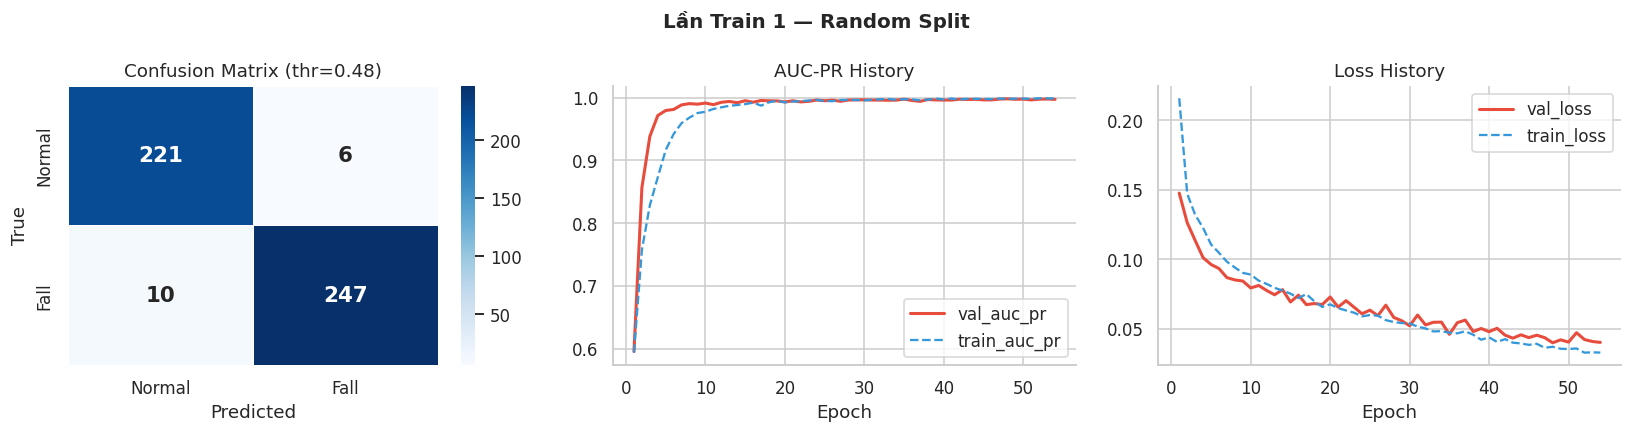

TN=221 | FP=6 (False Alarm) | FN=10 (Miss ⚠️) | TP=247
False Alarm Rate   : 2.64%
Miss Detection Rate: 3.89%


In [ ]:
# ============================================================
# CELL 8: ĐÁNH GIÁ LẦN TRAIN 1
# ============================================================
# Load best checkpoint (epoch tốt nhất theo val_auc_pr).
# Tìm threshold tối ưu TRÊN VAL — không được dùng test để tránh data leakage.
# Sau đó apply threshold lên test set để đánh giá cuối cùng.

best1 = keras.models.load_model(
    ckpt1,
    custom_objects={'MultiHeadSelfAttention': MultiHeadSelfAttention},
    compile=False
)
best1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss_fn,
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(name='auc_pr', curve='PR')]
)

# Tìm threshold trên VAL
y_val_prob = best1.predict(X_val_s, verbose=0).flatten()
prec_v, rec_v, thr_v = precision_recall_curve(y_val, y_val_prob)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)

# Threshold tối ưu F1
best_thr_f1 = float(thr_v[np.argmax(f1_v[:-1])]) if len(thr_v) > 0 else 0.5

# Threshold ưu tiên Recall >= 0.90
# Fall detection: bỏ sót ngã (FN) nguy hiểm hơn báo nhầm (FP)
# Nếu muốn an toàn hơn → dùng recall_thr thay vì best_thr_f1
recall_idxs = np.where(rec_v >= 0.90)[0]
recall_thr  = float(thr_v[recall_idxs[-1]]) if len(recall_idxs) > 0 else best_thr_f1

print(f'Threshold tối ưu F1     : {best_thr_f1:.3f}')
print(f'Threshold Recall ≥ 0.90 : {recall_thr:.3f}')

# Chọn threshold — đổi thành recall_thr nếu muốn ưu tiên an toàn
FINAL_THR1 = best_thr_f1
print(f'→ Dùng threshold        : {FINAL_THR1:.3f}\n')

# Predict trên test
y_test_prob = best1.predict(X_test_s, verbose=0).flatten()
y_test_pred = (y_test_prob >= FINAL_THR1).astype(int)

test_loss, test_acc, test_prec, test_rec, test_auc, test_auc_pr = \
    best1.evaluate(X_test_s, y_test, verbose=0)
test_f1 = f1_score(y_test, y_test_pred)

print('=' * 52)
print('   Lần Train 1 (Random Split) — Kết quả Test')
print('=' * 52)
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}  ← bắt được bao nhiêu % cú ngã')
print(f'  F1-Score  : {test_f1:.4f}')
print(f'  AUC-ROC   : {test_auc:.4f}')
print(f'  AUC-PR    : {test_auc_pr:.4f}')
print(f'  Threshold : {FINAL_THR1:.3f}')
print('=' * 52)
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES, digits=4))

cm1 = confusion_matrix(y_test, y_test_pred)
tn1, fp1, fn1, tp1 = cm1.ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Lần Train 1 — Random Split', fontsize=13, fontweight='bold')

# Confusion matrix
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, annot_kws={'size':14,'weight':'bold'}, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix (thr={FINAL_THR1:.2f})')

# AUC-PR history
hist1 = history1.history
ep1   = range(1, len(hist1['loss']) + 1)
axes[1].plot(ep1, hist1['val_auc_pr'], label='val_auc_pr', color='#e74c3c', lw=2)
axes[1].plot(ep1, hist1['auc_pr'],     label='train_auc_pr', color='#3498db', lw=1.5, ls='--')
axes[1].set_title('AUC-PR History'); axes[1].set_xlabel('Epoch')
axes[1].legend(); sns.despine(ax=axes[1])

# Loss history
axes[2].plot(ep1, hist1['val_loss'], label='val_loss', color='#e74c3c', lw=2)
axes[2].plot(ep1, hist1['loss'],     label='train_loss', color='#3498db', lw=1.5, ls='--')
axes[2].set_title('Loss History'); axes[2].set_xlabel('Epoch')
axes[2].legend(); sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results_split_v3.png', dpi=150)
plt.show()

print(f'TN={tn1} | FP={fp1} (False Alarm) | FN={fn1} (Miss ⚠️) | TP={tp1}')
print(f'False Alarm Rate   : {fp1/max(fp1+tn1,1):.2%}')
print(f'Miss Detection Rate: {fn1/max(fn1+tp1,1):.2%}')

In [ ]:
# ============================================================
# CELL 9: LƯU MODEL LẦN TRAIN 1
# ============================================================
# Lưu model .keras, scaler .pkl, config .json và TFLite .tflite.
# config.json chứa threshold và metadata — cần thiết khi deploy.

path_model1  = OUTPUT_DIR / 'fall_detection_v3_split.keras'
path_scaler1 = OUTPUT_DIR / 'scaler_v3_split.pkl'
path_config1 = OUTPUT_DIR / 'config_v3_split.json'
path_tflite1 = OUTPUT_DIR / 'fall_detection_v3_split.tflite'

best1.save(path_model1)
print(f'✅ Model  : {path_model1}')

with open(path_scaler1, 'wb') as f:
    pickle.dump(scaler1, f)
print(f'✅ Scaler : {path_scaler1}')

cfg1 = {
    'version'           : 'v3_split',
    'architecture'      : 'CNN + LSTM (1-dir) + MultiHeadAttention',
    'train_mode'        : 'random_split',
    'n_hot_windows'     : N_HOT_WINDOWS,
    'sample_rate'       : SAMPLE_RATE,
    'window_size'       : WINDOW_SIZE,
    'num_channels'      : NUM_CHANNELS,
    'overlap_ratio'     : OVERLAP_RATIO,
    'threshold'         : FINAL_THR1,
    'threshold_recall90': recall_thr,
    'class_names'       : CLASS_NAMES,
    'subjects'          : sorted(set(p for _, _, p in all_sessions)),
    'metrics': {
        'test_accuracy' : round(float(test_acc),    4),
        'test_precision': round(float(test_prec),   4),
        'test_recall'   : round(float(test_rec),    4),
        'test_f1'       : round(float(test_f1),     4),
        'test_auc_roc'  : round(float(test_auc),    4),
        'test_auc_pr'   : round(float(test_auc_pr), 4),
        'confusion'     : {'TN':int(tn1),'FP':int(fp1),'FN':int(fn1),'TP':int(tp1)},
    },
}
with open(path_config1, 'w') as f:
    json.dump(cfg1, f, indent=2)
print(f'✅ Config : {path_config1}')

# Export TFLite — dùng để deploy trên mobile/embedded
try:
    conv = tf.lite.TFLiteConverter.from_keras_model(best1)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization nhẹ
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,   # cần cho MultiHeadAttention
    ]
    conv._experimental_lower_tensor_list_ops = False
    tflite_bytes = conv.convert()
    with open(path_tflite1, 'wb') as f:
        f.write(tflite_bytes)
    kb = os.path.getsize(path_tflite1) / 1024
    print(f'✅ TFLite : {path_tflite1}  ({kb:.1f} KB)')
except Exception as e:
    print(f'⚠️  TFLite skip: {e}')

print(f'\n✅ Lưu xong lần train 1. F1={test_f1:.4f} | Recall={test_rec:.4f}')

✅ Model  : /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/fall_detection_v3_split.keras
✅ Scaler : /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/scaler_v3_split.pkl
✅ Config : /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/config_v3_split.json
Saved artifact at '/tmp/tmpvafks_24'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 6), dtype=tf.float32, name='imu_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139636212538000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139636212533584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139636212536656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139636212538576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139636212538384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139636212534160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139636212539152: TensorSpec(shape=(), dtyp

In [ ]:
# ============================================================
# CELL 10: LẦN TRAIN 2 — LEAVE-ONE-SUBJECT-OUT (LOSO)
# ============================================================
#
# MỤC ĐÍCH: Đánh giá model trên NGƯỜI HOÀN TOÀN MỚI.
#   Mỗi fold: N-1 subjects train, 1 subject test (không có trong train).
#   → Phản ánh đúng performance khi deploy cho người chưa từng dùng hệ thống.
#   → Tiêu chuẩn đánh giá phổ biến nhất trong fall detection research.
#
# Mỗi fold build model mới từ đầu → tránh weight leakage giữa các folds.
# Scaler fit riêng trên train của mỗi fold → không leak thông tin từ test subject.
# Threshold tìm trên val (không phải test) của mỗi fold.
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    precision_recall_curve, classification_report
)
unique_subjects = sorted(set(persons_raw))
n_folds = len(unique_subjects)

print('═' * 60)
print(f'  LẦN TRAIN 2: LOSO — {n_folds} FOLDS')
print('═' * 60)
print(f'Subjects: {unique_subjects}')

loso_results = {
    'f1':[], 'precision':[], 'recall':[], 'auc_roc':[], 'auc_pr':[],
    'tn':[], 'fp':[], 'fn':[], 'tp':[], 'threshold':[], 'test_subject':[]
}

for fold, test_subj in enumerate(unique_subjects):
    train_subjs = [s for s in unique_subjects if s != test_subj]
    print(f'\n{"─"*55}')
    print(f'Fold {fold+1}/{n_folds}: TEST={test_subj} | TRAIN={train_subjs}')
    print(f'{"─"*55}')

    train_mask = (persons_raw != test_subj)
    test_mask  = (persons_raw == test_subj)

    X_tr, y_tr = X_raw[train_mask], y_raw[train_mask]
    X_te, y_te = X_raw[test_mask],  y_raw[test_mask]

    print(f'Train: {len(X_tr)} (N={int(np.sum(y_tr==0))}, F={int(np.sum(y_tr==1))})')
    print(f'Test : {len(X_te)} (N={int(np.sum(y_te==0))}, F={int(np.sum(y_te==1))})')

    # Bỏ qua fold nếu test subject thiếu 1 class (không tính được metrics)
    if np.sum(y_te == 1) == 0 or np.sum(y_te == 0) == 0:
        print(f'⚠️  Fold {fold+1}: test set thiếu class → bỏ qua')
        continue

    # Scale fit trên train fold — không dùng thông tin từ test subject
    sc_fold = StandardScaler()
    X_tr_s  = sc_fold.fit_transform(
        X_tr.reshape(-1, NUM_CHANNELS)
    ).reshape(-1, WINDOW_SIZE, NUM_CHANNELS).astype(np.float32)
    X_te_s  = sc_fold.transform(
        X_te.reshape(-1, NUM_CHANNELS)
    ).reshape(-1, WINDOW_SIZE, NUM_CHANNELS).astype(np.float32)

    # Tách val từ train — stratified để val có đủ cả 2 class
    X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
        X_tr_s, y_tr.astype(np.float32),
        test_size=0.15,
        random_state=SEED + fold,
        stratify=y_tr
    )
    print(f'Train sau val split: {len(X_tr2)} | Val: {len(X_val2)}')

    # Class weight cho fold này
    cw_f      = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
    cw_f_dict = {0: float(cw_f[0]), 1: float(cw_f[1])}

    # Build model mới hoàn toàn — không dùng lại weight từ fold trước
    tf.random.set_seed(SEED + fold)
    fold_model = build_model(input_shape=(WINDOW_SIZE, NUM_CHANNELS))
    fold_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss=focal_loss_fn,
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc_pr', curve='PR')]
    )

    fold_ckpt = OUTPUT_DIR / f'loso_fold{fold+1}_{test_subj}.keras'

    fold_model.fit(
        X_tr2, y_tr2,
        validation_data=(X_val2, y_val2),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=cw_f_dict,
        callbacks=[
            keras.callbacks.LearningRateScheduler(cosine_decay_with_warmup, verbose=0),
            callbacks.EarlyStopping(
                monitor='val_auc_pr', mode='max', patience=25,
                restore_best_weights=True, min_delta=0.002, verbose=1
            ),
            callbacks.ModelCheckpoint(
                str(fold_ckpt), monitor='val_auc_pr', mode='max',
                save_best_only=True, verbose=0
            ),
        ],
        verbose=1
    )

    # Predict trên test fold
    y_prob_te = fold_model.predict(X_te_s, verbose=0).flatten()

    # Tìm threshold tối ưu trên VAL (không phải test) — tránh data leakage
    y_prob_val2 = fold_model.predict(X_val2, verbose=0).flatten()
    prec_f, rec_f, thr_f = precision_recall_curve(y_val2.astype(int), y_prob_val2)
    f1_f     = 2 * prec_f * rec_f / (prec_f + rec_f + 1e-8)
    fold_thr = float(thr_f[np.argmax(f1_f[:-1])]) if len(thr_f) > 0 else 0.5
    y_pred_te = (y_prob_te >= fold_thr).astype(int)

    # Tính metrics từ threshold đã chọn — không dùng .evaluate() để tránh sai threshold
    fold_f1   = f1_score(y_te, y_pred_te, zero_division=0)
    fold_prec = precision_score(y_te, y_pred_te, zero_division=0)
    fold_rec  = recall_score(y_te, y_pred_te, zero_division=0)
    fold_auc  = roc_auc_score(y_te, y_prob_te)
    prec_c, rec_c, _ = precision_recall_curve(y_te, y_prob_te)
    fold_auc_pr = float(np.trapz(rec_c[::-1], prec_c[::-1]))

    cm_f = confusion_matrix(y_te, y_pred_te)
    tn_f, fp_f, fn_f, tp_f = cm_f.ravel()

    loso_results['f1'].append(fold_f1)
    loso_results['precision'].append(fold_prec)
    loso_results['recall'].append(fold_rec)
    loso_results['auc_roc'].append(fold_auc)
    loso_results['auc_pr'].append(fold_auc_pr)
    loso_results['tn'].append(int(tn_f))
    loso_results['fp'].append(int(fp_f))
    loso_results['fn'].append(int(fn_f))
    loso_results['tp'].append(int(tp_f))
    loso_results['threshold'].append(fold_thr)
    loso_results['test_subject'].append(test_subj)

    print(f'\n✅ Fold {fold+1} ({test_subj}): '
          f'F1={fold_f1:.4f} | Rec={fold_rec:.4f} | '
          f'AUC={fold_auc:.4f} | thr={fold_thr:.3f}')
    print(f'   TN={tn_f} | FP={fp_f}(False Alarm) | '
          f'FN={fn_f}(Miss⚠️) | TP={tp_f}')

print(f'\n✅ LOSO xong. {len(loso_results["f1"])}/{n_folds} folds hợp lệ.')

════════════════════════════════════════════════════════════
  LẦN TRAIN 2: LOSO — 7 FOLDS
════════════════════════════════════════════════════════════
Subjects: [np.str_('An'), np.str_('Cong'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]

───────────────────────────────────────────────────────
Fold 1/7: TEST=An | TRAIN=[np.str_('Cong'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]
───────────────────────────────────────────────────────
Train: 2819 (N=1349, F=1470)
Test : 402 (N=160, F=242)
Train sau val split: 2396 | Val: 423
Epoch 1/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.5417 - auc_pr: 0.5906 - loss: 0.2475 - precision: 0.5670 - recall: 0.5116 - val_accuracy: 0.6643 - val_auc_pr: 0.7688 - val_loss: 0.1496 - val_precision: 0.7616 - val_recall: 0.5204 - learning_rate: 5.0000e-05
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.6636 - auc_pr: 0.7076 - loss: 0.1690 - pre

═════════════════════════════════════════════════════════════════
   KẾT QUẢ LOSO — CNN + LSTM + MHA (7 Folds)
═════════════════════════════════════════════════════════════════
Subject         F1   Recall    Prec   AUC-ROC  FN(Miss)  FP(Alarm)
─────────────────────────────────────────────────────────────────
An          0.9437   0.9008  0.9909    0.9922        24          2
Cong        0.9005   0.9500  0.8559    0.9767        15         48
Hao         0.8655   0.8306  0.9035    0.9528        42         22
Hieu        0.9418   0.9843  0.9029    0.9925         4         27
Kien        0.9385   0.9767  0.9032    0.9747         4         18
Quan        0.8655   0.9597  0.7881    0.9640        10         64
Tien        0.9103   0.8623  0.9638    0.9684        34          8
─────────────────────────────────────────────────────────────────
Mean        0.9094   0.9235  0.9012    0.9745
Std         0.0317   0.0553  0.0619    0.0134
═══════════════════════════════════════════════════════════════

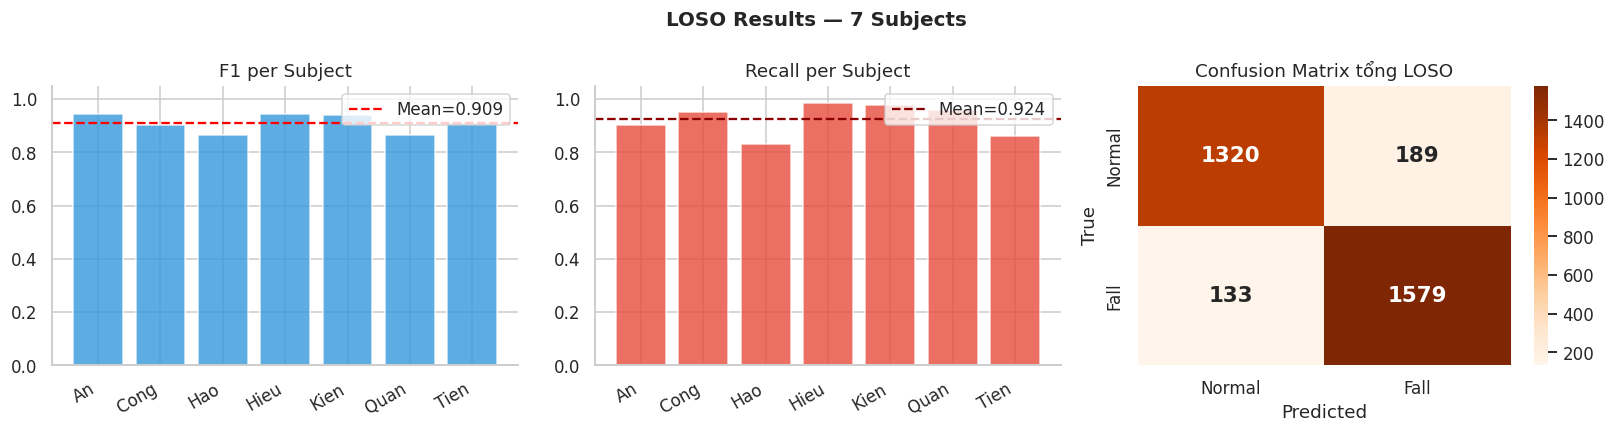

In [ ]:
# ============================================================
# CELL 11: TỔNG KẾT LOSO
# ============================================================
# In bảng kết quả từng subject và confusion matrix tổng hợp.
# Subject nào có F1 thấp → cần thu thêm data hoặc kiểm tra chất lượng data.

n_folds = len(loso_results['test_subject'])

print('═' * 65)
print(f'   KẾT QUẢ LOSO — CNN + LSTM + MHA ({n_folds} Folds)')
print('═' * 65)
print(f'{"Subject":<10} {"F1":>7} {"Recall":>8} {"Prec":>7} '
      f'{"AUC-ROC":>9} {"FN(Miss)":>9} {"FP(Alarm)":>10}')
print('─' * 65)
for i, subj in enumerate(loso_results['test_subject']):
    print(f'{subj:<10} '
          f'{loso_results["f1"][i]:>7.4f} '
          f'{loso_results["recall"][i]:>8.4f} '
          f'{loso_results["precision"][i]:>7.4f} '
          f'{loso_results["auc_roc"][i]:>9.4f} '
          f'{loso_results["fn"][i]:>9} '
          f'{loso_results["fp"][i]:>10}')
print('─' * 65)
print(f'{"Mean":<10} '
      f'{np.mean(loso_results["f1"]):>7.4f} '
      f'{np.mean(loso_results["recall"]):>8.4f} '
      f'{np.mean(loso_results["precision"]):>7.4f} '
      f'{np.mean(loso_results["auc_roc"]):>9.4f}')
print(f'{"Std":<10} '
      f'{np.std(loso_results["f1"]):>7.4f} '
      f'{np.std(loso_results["recall"]):>8.4f} '
      f'{np.std(loso_results["precision"]):>7.4f} '
      f'{np.std(loso_results["auc_roc"]):>9.4f}')
print('═' * 65)

total_tn = sum(loso_results['tn'])
total_fp = sum(loso_results['fp'])
total_fn = sum(loso_results['fn'])
total_tp = sum(loso_results['tp'])
print(f'\nTổng confusion matrix (LOSO):')
print(f'  TN={total_tn} | FP={total_fp} ← False Alarm (báo nhầm)')
print(f'  FN={total_fn} ← Miss ⚠️ (bỏ sót ngã) | TP={total_tp}')
print(f'  False Alarm Rate   : {total_fp/max(total_fp+total_tn,1):.2%}')
print(f'  Miss Detection Rate: {total_fn/max(total_fn+total_tp,1):.2%}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'LOSO Results — {n_folds} Subjects', fontsize=13, fontweight='bold')

subjs = loso_results['test_subject']
x_pos = np.arange(n_folds)

axes[0].bar(x_pos, loso_results['f1'], color='#3498db', alpha=0.8)
axes[0].axhline(np.mean(loso_results['f1']), color='red', ls='--',
                label=f'Mean={np.mean(loso_results["f1"]):.3f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(subjs, rotation=30 if n_folds > 6 else 0, ha='right')
axes[0].set_title('F1 per Subject'); axes[0].set_ylim(0, 1.05)
axes[0].legend(); sns.despine(ax=axes[0])

axes[1].bar(x_pos, loso_results['recall'], color='#e74c3c', alpha=0.8)
axes[1].axhline(np.mean(loso_results['recall']), color='darkred', ls='--',
                label=f'Mean={np.mean(loso_results["recall"]):.3f}')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(subjs, rotation=30 if n_folds > 6 else 0, ha='right')
axes[1].set_title('Recall per Subject'); axes[1].set_ylim(0, 1.05)
axes[1].legend(); sns.despine(ax=axes[1])

cm_total = np.array([[total_tn, total_fp], [total_fn, total_tp]])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size':14,'weight':'bold'}, ax=axes[2])
axes[2].set_title('Confusion Matrix tổng LOSO')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results_loso_v3.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 12: MODEL CUỐI CÙNG ĐỂ DEPLOY
# ============================================================
#
# Tại sao cần train lại lần này?
#   Lần train 1: chỉ dùng 70% data (còn val 15% + test 15% không train)
#   Lần train 2 (LOSO): mỗi fold chỉ dùng N-1 subjects
#   → Cả hai đều bỏ phí một phần data
#
# Model này: train trên TOÀN BỘ data của tất cả subjects
#   → Dùng nhiều data nhất có thể → tổng quát tốt nhất khi deploy
#   → Giữ lại 10% val để tìm threshold và early stopping
#
# Đây là model thực tế để tích hợp vào app / thiết bị.

n_subjects = len(sorted(set(persons_raw)))

print(f'🚀 Train model CUỐI CÙNG để deploy...')
print(f'   (Toàn bộ {n_subjects} subjects, tận dụng hết data)\n')

# Scale trên toàn bộ data
scaler_final = StandardScaler()
scaler_final.fit(X_raw.reshape(-1, NUM_CHANNELS))
X_all_s = scaler_final.transform(
    X_raw.reshape(-1, NUM_CHANNELS)
).reshape(-1, WINDOW_SIZE, NUM_CHANNELS).astype(np.float32)

# Giữ 10% val để tìm threshold và early stopping
X_dep_tr, X_dep_val, y_dep_tr, y_dep_val = train_test_split(
    X_all_s, y_raw.astype(np.float32),
    test_size=0.10, random_state=SEED, stratify=y_raw
)
print(f'Train: {len(X_dep_tr)} | Val: {len(X_dep_val)}')

cw_dep      = compute_class_weight('balanced', classes=np.array([0,1]), y=y_raw)
cw_dep_dict = {0: float(cw_dep[0]), 1: float(cw_dep[1])}

tf.random.set_seed(SEED + 99)
model_final = build_model(input_shape=(WINDOW_SIZE, NUM_CHANNELS))
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=focal_loss_fn,
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc_pr', curve='PR')]
)

ckpt_final = OUTPUT_DIR / 'fall_detection_v3_final.keras'
model_final.fit(
    X_dep_tr, y_dep_tr,
    validation_data=(X_dep_val, y_dep_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw_dep_dict,
    callbacks=[
        keras.callbacks.LearningRateScheduler(cosine_decay_with_warmup, verbose=0),
        callbacks.EarlyStopping(
            monitor='val_auc_pr', mode='max', patience=30,
            restore_best_weights=True, min_delta=0.002, verbose=1
        ),
        callbacks.ModelCheckpoint(
            str(ckpt_final), monitor='val_auc_pr', mode='max',
            save_best_only=True, verbose=1
        ),
    ],
    verbose=1
)

# Load best
best_final = keras.models.load_model(
    ckpt_final,
    custom_objects={'MultiHeadSelfAttention': MultiHeadSelfAttention},
    compile=False
)

# Tìm threshold trên val — không dùng test để tránh data leakage
y_dep_val_prob = best_final.predict(X_dep_val, verbose=0).flatten()
prec_d, rec_d, thr_d = precision_recall_curve(y_dep_val.astype(int), y_dep_val_prob)
f1_d      = 2 * prec_d * rec_d / (prec_d + rec_d + 1e-8)
final_thr  = float(thr_d[np.argmax(f1_d[:-1])]) if len(thr_d) > 0 else 0.5
print(f'\nFinal model threshold: {final_thr:.3f}')

# ── Lưu tất cả ───────────────────────────────────────────────
path_scaler_f = OUTPUT_DIR / 'scaler_v3_final.pkl'
path_config_f = OUTPUT_DIR / 'config_v3_final.json'
path_tflite_f = OUTPUT_DIR / 'fall_detection_v3_final.tflite'

with open(path_scaler_f, 'wb') as f:
    pickle.dump(scaler_final, f)
print(f'✅ Scaler : {path_scaler_f}')

cfg_final = {
    'version'         : 'v3_final',
    'architecture'    : 'CNN + LSTM (1-dir) + MultiHeadAttention',
    'train_mode'      : 'all_subjects_deploy',
    'n_hot_windows'   : N_HOT_WINDOWS,
    'sample_rate'     : SAMPLE_RATE,
    'window_size'     : WINDOW_SIZE,
    'num_channels'    : NUM_CHANNELS,
    'overlap_ratio'   : OVERLAP_RATIO,
    'threshold'       : final_thr,
    'class_names'     : CLASS_NAMES,
    'n_subjects'      : n_subjects,
    'subjects_trained': sorted(set(p for _,_,p in all_sessions)),
    'loso_summary': {
        'mean_f1'     : round(float(np.mean(loso_results['f1'])),    4),
        'std_f1'      : round(float(np.std(loso_results['f1'])),     4),
        'mean_recall' : round(float(np.mean(loso_results['recall'])),4),
        'mean_auc_roc': round(float(np.mean(loso_results['auc_roc'])),4),
    },
    'split_summary': {
        'test_f1'    : round(float(test_f1),     4),
        'test_recall': round(float(test_rec),     4),
        'test_auc_pr': round(float(test_auc_pr), 4),
    },
    'loso_per_subject': {
        subj: {
            'f1'      : round(loso_results['f1'][i],        4),
            'recall'  : round(loso_results['recall'][i],    4),
            'threshold': round(loso_results['threshold'][i], 3),
            'tn': loso_results['tn'][i], 'fp': loso_results['fp'][i],
            'fn': loso_results['fn'][i], 'tp': loso_results['tp'][i],
        }
        for i, subj in enumerate(loso_results['test_subject'])
    }
}
with open(path_config_f, 'w') as f:
    json.dump(cfg_final, f, indent=2)
print(f'✅ Config : {path_config_f}')

try:
    conv = tf.lite.TFLiteConverter.from_keras_model(best_final)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    conv._experimental_lower_tensor_list_ops = False
    tflite_bytes = conv.convert()
    with open(path_tflite_f, 'wb') as f:
        f.write(tflite_bytes)
    kb = os.path.getsize(path_tflite_f) / 1024
    print(f'✅ TFLite : {path_tflite_f}  ({kb:.1f} KB)')
except Exception as e:
    print(f'⚠️  TFLite skip: {e}')

# ── TỔNG KẾT CUỐI CÙNG ───────────────────────────────────────
n_loso = len(loso_results['test_subject'])
print('\n' + '═' * 62)
print('   TỔNG KẾT TOÀN BỘ')
print('═' * 62)
print(f'{"Metric":<15} {"Train 1 (Split)":>18} {"Train 2 (LOSO)":>18}')
print('─' * 62)
print(f'{"F1-Score":<15} {test_f1:>18.4f} '
      f'{np.mean(loso_results["f1"]):>13.4f} ±{np.std(loso_results["f1"]):.4f}')
print(f'{"Recall":<15} {test_rec:>18.4f} '
      f'{np.mean(loso_results["recall"]):>13.4f} ±{np.std(loso_results["recall"]):.4f}')
print(f'{"AUC-ROC":<15} {test_auc:>18.4f} '
      f'{np.mean(loso_results["auc_roc"]):>13.4f} ±{np.std(loso_results["auc_roc"]):.4f}')
print('═' * 62)
print(f'\n📝 Ghi chú:')
print(f'  Train 1 (Split) : data lẫn lộn → kết quả OPTIMISTIC (quá đẹp)')
print(f'  Train 2 (LOSO)  : test người mới → kết quả THỰC TẾ hơn ({n_loso} folds)')
print(f'  Model deploy    : {ckpt_final}')
print(f'  Scaler deploy   : {path_scaler_f}')
print(f'  Config deploy   : {path_config_f}')
print(f'  Threshold       : {final_thr:.3f}')
print(f'\n✅ Hoàn tất! Dùng file _final.keras + scaler_final.pkl để deploy.')

🚀 Train model CUỐI CÙNG để deploy...
   (Toàn bộ 7 subjects, tận dụng hết data)

Train: 2898 | Val: 323
Epoch 1/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5104 - auc_pr: 0.5148 - loss: 0.2272 - precision: 0.5211 - recall: 0.5810
Epoch 1: val_auc_pr improved from None to 0.66076, saving model to /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/fall_detection_v3_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/data_pbl5/models_7_pers_lstm/fall_detection_v3_final.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - accuracy: 0.5528 - auc_pr: 0.5778 - loss: 0.2055 - precision: 0.5688 - recall: 0.6545 - val_accuracy: 0.5851 - val_auc_pr: 0.6608 - val_loss: 0.1546 - val_precision: 0.5841 - val_recall: 0.7674 - learning_rate: 5.0000e-05
Epoch 2/150
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6575 - auc_pr: 0.7259 - loss: 0.1582 - precision: 0.6329 - recall: 0.8042
Epoch 2: val_auc_pr improved from 0.66076 to 0.87824, saving model to /content/dri